## Geological Interpretation for Open vs. Closed System Analysis

Crystallinity-Insensitive Ratios: Sr/Ba: Both behave similarly during plagioclase crystallization. Rb/Sr: K-feldspar vs plagioclase compatibility contrast. La/Y: Heavy vs light REE behavior, insensitive to major phases. These ratios change due to melt evolution processes, not just mineral crystallization.

How to Interpret the Results:
1. Ratio Profile Patterns:
A. Closed System Indicators (Smooth Trends): Smooth, monotonic changes with distance. High R² values (>0.7) for linear fits. Few reversals or breaks. Consistent trends across all ratios. Interpretation: Rayleigh fractionation, no external inputs

B. Open System Indicators (Breaks/Reversals): Abrupt changes in ratio trends. Low R² values (<0.3) for linear fits. ultiple reversals in trends. Decoupled behavior between different ratios. Interpretation: Recharge, assimilation, mixing, or fluid influx

2. Core-Rim Comparison:
Expected Patterns: Closed system: Smooth evolution from core to rim. Open system: Discontinuous changes, core and rim may have different origins. Recharge events: Rim compositions may revert to more primitive values

3. Ratio Cross-Correlations:
What to Look For: Strong correlations between ratios → Coherent evolution. Weak correlations → Decoupled processes. Negative correlations → Opposing controls on elements. Specific Ratio Interpretations:
Sr/Ba Ratio:
Increasing Sr/Ba: Plagioclase-dominated fractionation. Decreasing Sr/Ba: K-feldspar or biotite influence. Constant Sr/Ba: No feldspar control, or balanced removal

Rb/Sr Ratio:
Increasing Rb/Sr: K-feldspar fractionation or crustal assimilation. Decreasing Rb/Sr: Plagioclase accumulation or mafic input. High Rb/Sr: Evolved, crustal signatures

La/Y Ratio:
Increasing La/Y: Amphibole or garnet fractionation
Decreasing La/Y: Plagioclase or clinopyroxene control
Variable La/Y: Complex REE mineralogy or multiple sources

System Behavior Assessment:
Likely Closed System If:
All ratios show smooth, correlated trends
High linear correlation coefficients (R² > 0.7)
Few trend reversals (<2 per transect)
Consistent core-to-rim evolution
Likely Open System If:

Ratios show breaks or reversals
Low correlation coefficients (R² < 0.3)
Many trend reversals (>3 per transect)
Decoupled behavior between ratios
Core and rim have statistically different compositions

What the Code Calculates:
Trend Analysis: Linear fits to identify smooth vs. broken trends. Reversal Detection: Counts significant changes in slope. Correlation Matrix: Shows how ratios relate to each other. Core-Rim Statistics: Quantifies compositional changes. System Behavior Score: Numerically assesses open vs. closed behavior

In [11]:
excel_file = r"C:\Users\bd489s\OneDrive - Missouri State University\THESIS\manuscripts\manuscript 2\traceelement_timeseries.xlsx"

In [2]:
# First, install statsmodels
!pip install statsmodels -q

# Now import it
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

print("statsmodels successfully installed and imported!")

statsmodels successfully installed and imported!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal, interpolate

# Set style for cleaner plots
plt.style.use('default')
sns.set_style("whitegrid")


Processing data for Open vs. Closed System Analysis...

Processing: Chao Dacite
Sheet: CHAO22-01.110 time series data
✓ Successfully loaded data
✓ Data points: 65
✓ Distance range: 0.0 to 139.7 μm

Processing: Chillahuita
Sheet: TORT22-01.112 time series data
✓ Successfully loaded data
✓ Data points: 130
✓ Distance range: 0.0 to 281.6 μm

Processing: Tocorpuri
Sheet: TOTO22-01.105 time series data
✓ Successfully loaded data
✓ Data points: 117
✓ Distance range: 0.0 to 253.3 μm

TOTAL DATA POINTS: 312
  Chao Dacite: 65 points
  Chillahuita: 130 points
  Tocorpuri: 117 points


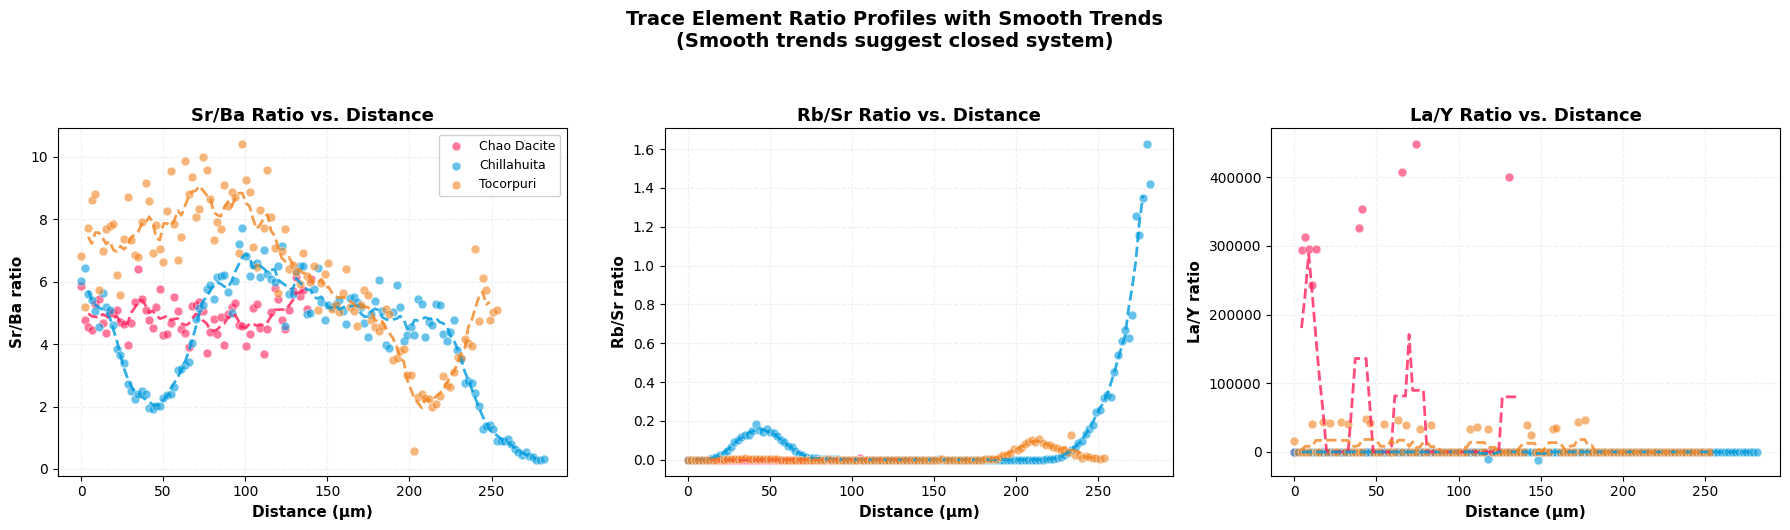

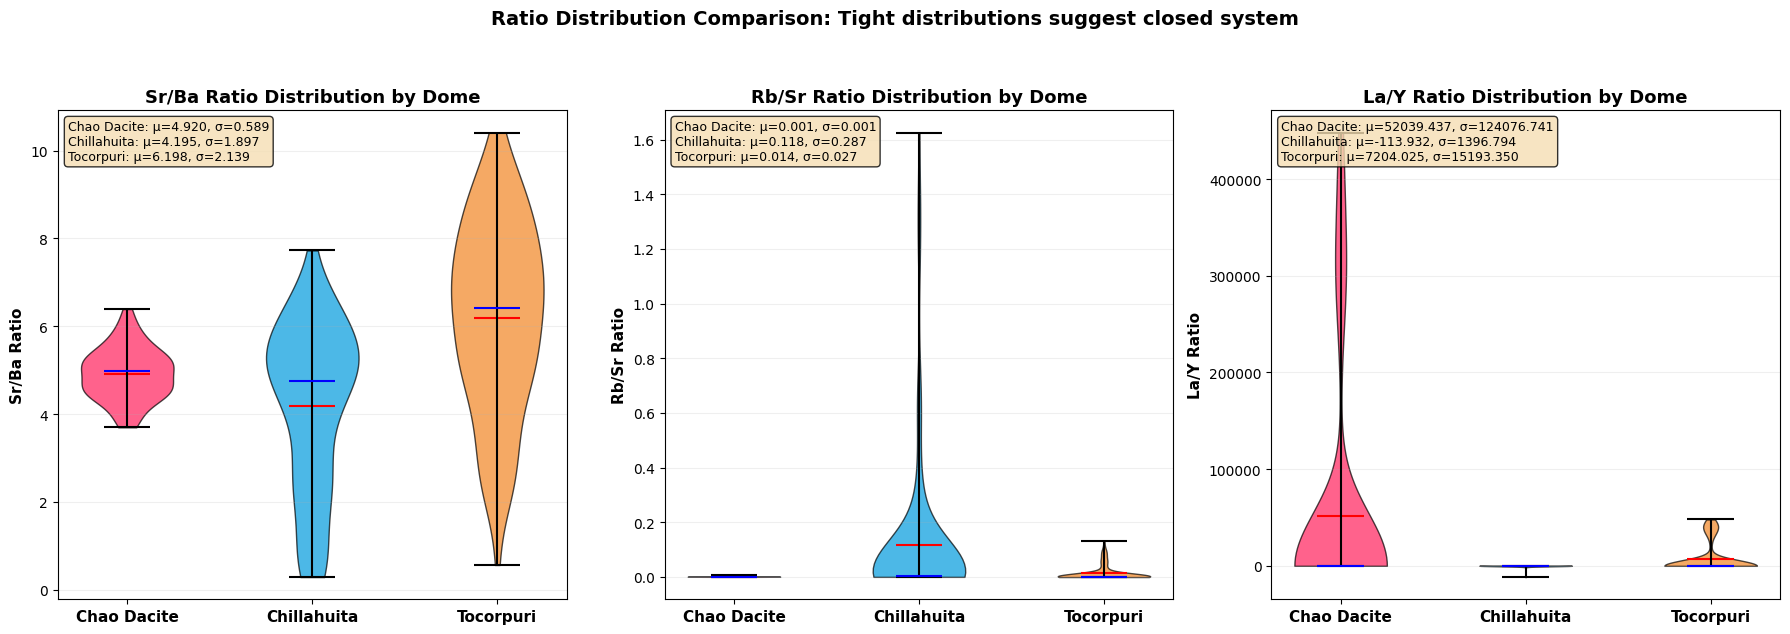

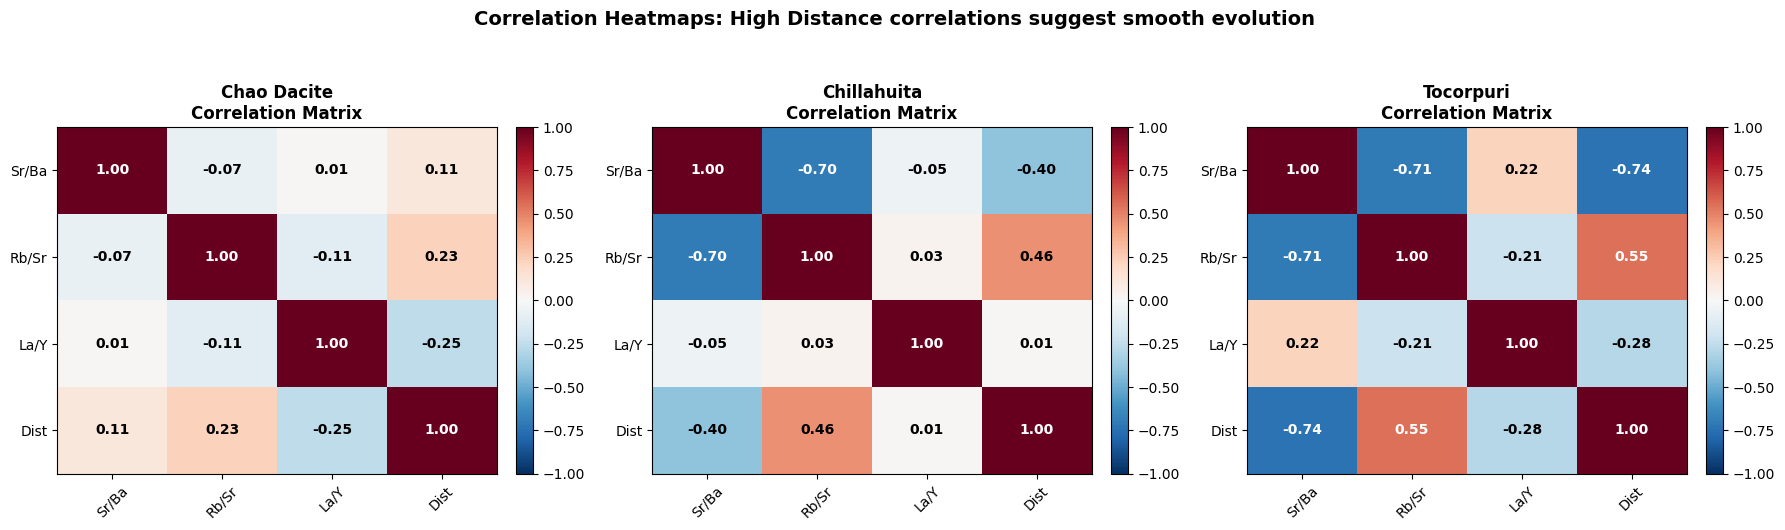

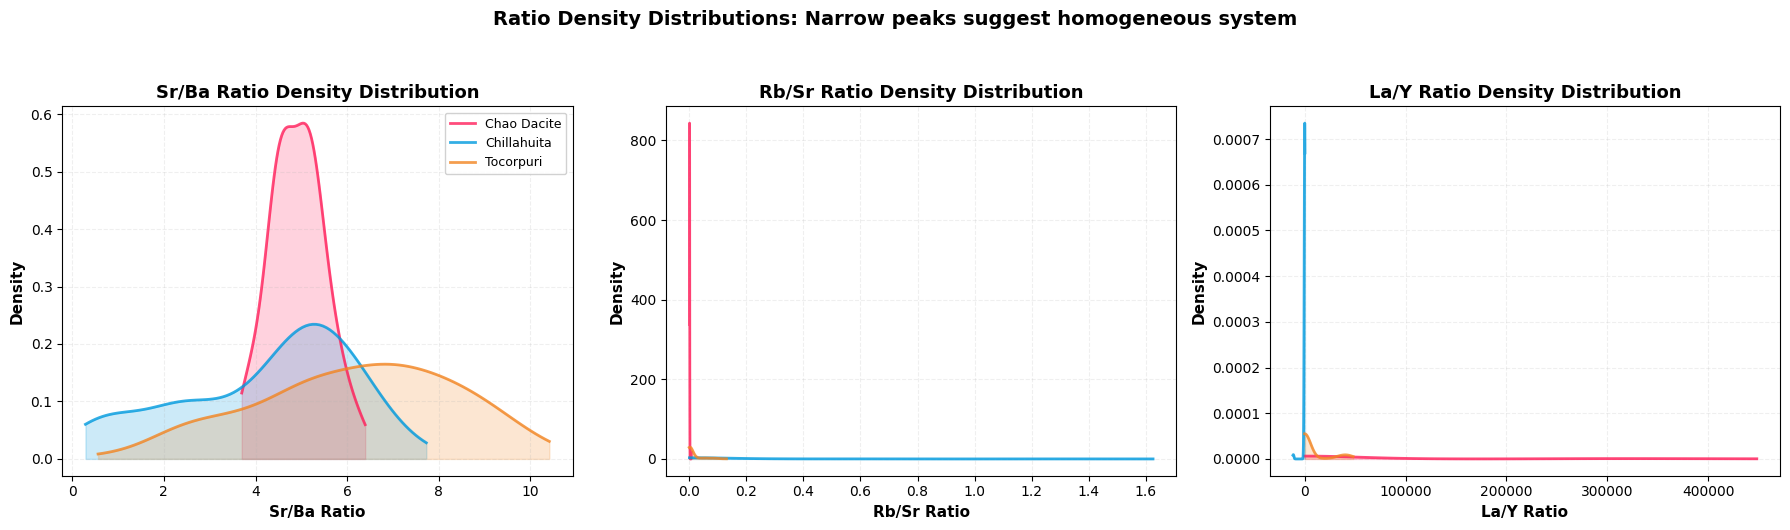

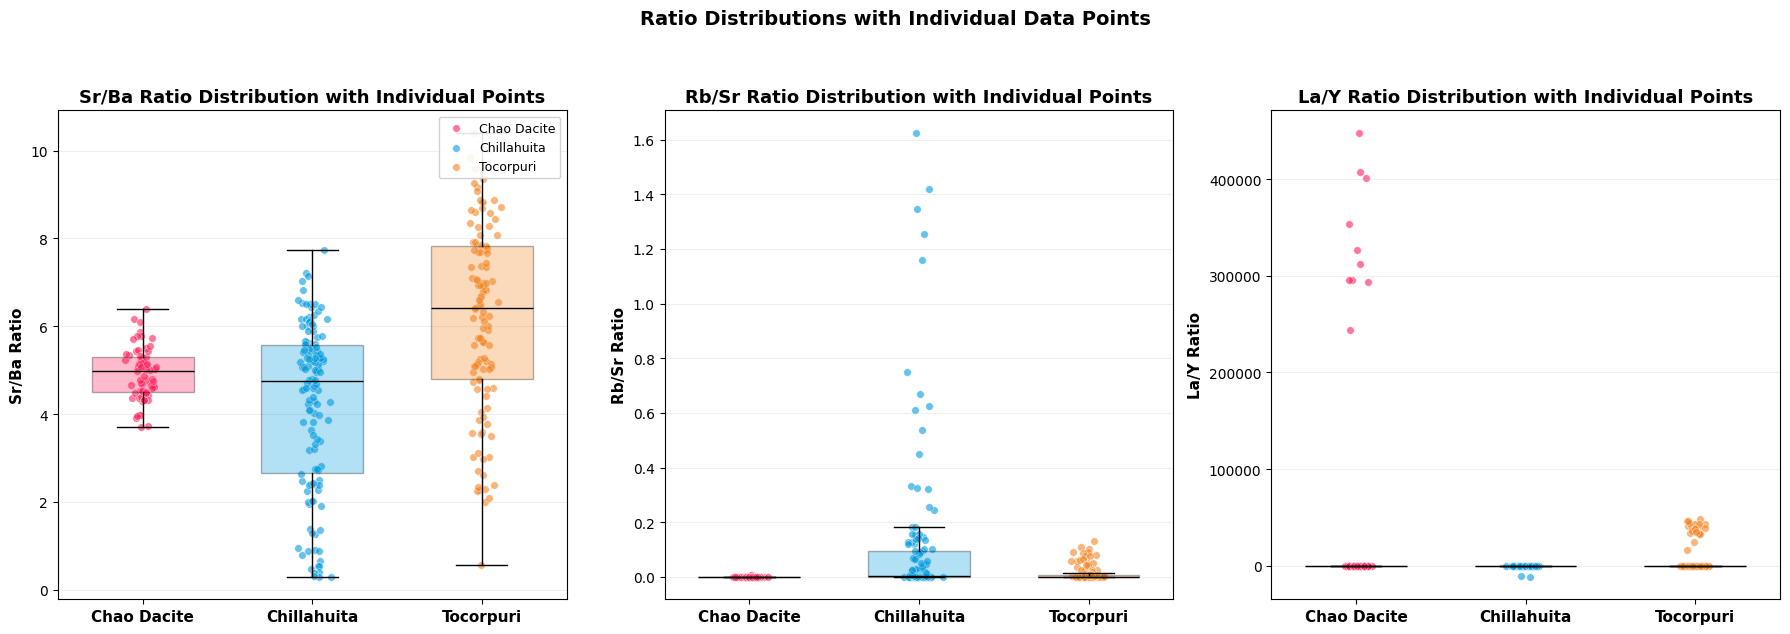


SYSTEM BEHAVIOR ASSESSMENT

Chao Dacite:
----------------------------------------
  Sr/Ba: R²=0.013, reversals=29 → Open
  Rb/Sr: R²=0.054, reversals=40 → Open
  La/Y: R²=0.064, reversals=40 → Open

  Overall: Avg R²=0.044, Total reversals=109
  Assessment: OPEN SYSTEM

Chillahuita:
----------------------------------------
  Sr/Ba: R²=0.159, reversals=52 → Open
  Rb/Sr: R²=0.211, reversals=48 → Open
  La/Y: R²=0.000, reversals=80 → Open

  Overall: Avg R²=0.123, Total reversals=180
  Assessment: OPEN SYSTEM

Tocorpuri:
----------------------------------------
  Sr/Ba: R²=0.541, reversals=65 → Open
  Rb/Sr: R²=0.302, reversals=57 → Open
  La/Y: R²=0.080, reversals=68 → Open

  Overall: Avg R²=0.308, Total reversals=190
  Assessment: OPEN SYSTEM

SUMMARY OF ASSESSMENTS
Dome            Avg R²     Reversals    Assessment          
------------------------------------------------------------
Chao Dacite          0.044          109 OPEN SYSTEM         
Chillahuita          0.123          18

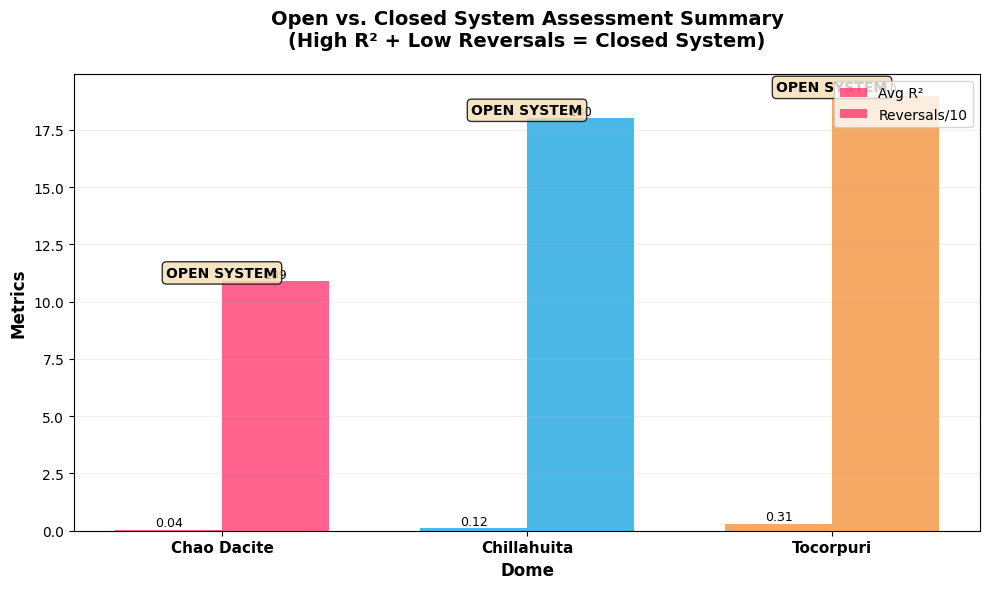

In [13]:

# Define the specific sheets we need with dome names and colors
dome_info = {
    'Chao Dacite': {
        'sheet': 'CHAO22-01.110 time series data',
        'color': '#FF1F5B'
    },
    'Chillahuita': {
        'sheet': 'TORT22-01.112 time series data',
        'color': '#009ADE'
    },
    'Tocorpuri': {
        'sheet': 'TOTO22-01.105 time series data',
        'color': '#F28522'
    }
}
# Read and process each sheet
all_data = []
print("Processing data for Open vs. Closed System Analysis...")
print("="*60)

for dome_name, info in dome_info.items():
    print(f"\nProcessing: {dome_name}")
    print(f"Sheet: {info['sheet']}")
    try:
        # Read the sheet with headers in row 0 (first row)
        df = pd.read_excel(excel_file, sheet_name=info['sheet'], header=0)
        
        print(f"✓ Successfully loaded data")
        # Create distance column (Elapsed Time * 10 micrometers)
        df['Distance_um'] = df['Elapsed Time'] * 10
        # Create processed dataframe with direct element columns
        processed_df = pd.DataFrame({
            'Dome': dome_name,
            'Distance_um': df['Distance_um'],
            'Color': info['color'],
            'Sr_ppm': df['Sr'],
            'Ba_ppm': df['Ba'],
            'Rb_ppm': df['Rb'],
            'La_ppm': df['La'],
            'Y_ppm': df['Y']
        })
        
        # Calculate ratios
        processed_df['Sr_Ba_ratio'] = processed_df['Sr_ppm'] / processed_df['Ba_ppm']
        processed_df['Rb_Sr_ratio'] = processed_df['Rb_ppm'] / processed_df['Sr_ppm']
        processed_df['La_Y_ratio'] = processed_df['La_ppm'] / processed_df['Y_ppm']
        
        # Remove rows with NaN values
        processed_df = processed_df.dropna()
        print(f"✓ Data points: {len(processed_df)}")
        print(f"✓ Distance range: {processed_df['Distance_um'].min():.1f} to {processed_df['Distance_um'].max():.1f} μm")
        
        all_data.append(processed_df)
        
    except Exception as e:
        print(f"✗ Error: {str(e)}")

# Combine all data
if all_data:
    combined_data = pd.concat(all_data, ignore_index=True)
    
    print("\n" + "="*60)
    print(f"TOTAL DATA POINTS: {len(combined_data)}")
    for dome_name in dome_info.keys():
        dome_count = len(combined_data[combined_data['Dome'] == dome_name])
        print(f"  {dome_name}: {dome_count} points")
    print("="*60)
    
    # =============================================
    # PLOT 1: SCATTER PLOTS WITH SAVITZKY-GOLAY SMOOTHING
    # =============================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ratios = ['Sr_Ba_ratio', 'Rb_Sr_ratio', 'La_Y_ratio']
    ratio_names = ['Sr/Ba', 'Rb/Sr', 'La/Y']
    ratio_units = ['ratio', 'ratio', 'ratio']
    
    for idx, (ratio, name, unit) in enumerate(zip(ratios, ratio_names, ratio_units)):
        ax = axes[idx]
        
        for dome_name, dome_data in combined_data.groupby('Dome'):
            color = dome_info[dome_name]['color']
            
            # Sort by distance for proper smoothing
            dome_data_sorted = dome_data.sort_values('Distance_um')
            
            # Create scatter plot
            scatter = ax.scatter(dome_data_sorted['Distance_um'], dome_data_sorted[ratio],
                                alpha=0.5, s=40, label=dome_name,
                                color=color, edgecolors='white', linewidth=0.5)
            
            # Add Savitzky-Golay smoothing (similar to LOESS but built-in)
            try:
                if len(dome_data_sorted) > 10:
                    # Determine window size (odd number, less than data length)
                    window_length = min(15, len(dome_data_sorted) // 2 * 2 + 1)
                    if window_length >= 5:
                        y_smooth = signal.savgol_filter(dome_data_sorted[ratio], 
                                                       window_length=window_length, 
                                                       polyorder=2)
                        ax.plot(dome_data_sorted['Distance_um'], y_smooth, 
                               color=color, linewidth=2.5, alpha=0.8, 
                               label=f'{dome_name} trend')
                        
            except Exception as e:
                # Fallback to moving average
                window_size = min(5, len(dome_data_sorted) // 2)
                if window_size >= 2:
                    y_smooth = dome_data_sorted[ratio].rolling(window=window_size, center=True).mean()
                    ax.plot(dome_data_sorted['Distance_um'], y_smooth, 
                           color=color, linewidth=2, alpha=0.8, linestyle='--')
        
        ax.set_xlabel('Distance (μm)', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{name} {unit}', fontsize=11, fontweight='bold')
        #ax.set_title(f'{name} Ratio vs. Distance', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle='--')
        
        if idx == 0:  # Legend only on first plot
            ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
    
    plt.suptitle('Trace Element Ratio Profiles with Smooth Trends\n(Smooth trends suggest closed system)', 
                fontsize=14, fontweight='bold', y=1.05)
      ax.grid(False)
    plt.tight_layout()
    plt.savefig('Ratio_Scatter_Plots.png', dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()
    
  
    # =============================================
    # PLOT 3: HEATMAP OF CORRELATIONS
    # =============================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, dome_name in enumerate(dome_info.keys()):
        ax = axes[idx]
        dome_data = combined_data[combined_data['Dome'] == dome_name]
        
        if len(dome_data) > 1:
            # Select columns for correlation
            corr_cols = ['Sr_Ba_ratio', 'Rb_Sr_ratio', 'La_Y_ratio', 'Distance_um']
            corr_data = dome_data[corr_cols]
            
            # Calculate correlation matrix
            corr_matrix = corr_data.corr()
            
            # Create heatmap
            im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
            
            # Add text annotations
            for i in range(len(corr_matrix)):
                for j in range(len(corr_matrix)):
                    value = corr_matrix.iloc[i, j]
                    color = 'white' if abs(value) > 0.5 else 'black'
                    ax.text(j, i, f'{value:.2f}', ha='center', va='center', 
                           color=color, fontsize=10, fontweight='bold')
            
            # Customize axes
            ax.set_xticks(range(len(corr_matrix)))
            ax.set_yticks(range(len(corr_matrix)))
            ax.set_xticklabels(['Sr/Ba', 'Rb/Sr', 'La/Y', 'Dist'], fontsize=10, rotation=45)
            ax.set_yticklabels(['Sr/Ba', 'Rb/Sr', 'La/Y', 'Dist'], fontsize=10)
            ax.set_title(f'{dome_name}\nCorrelation Matrix', fontsize=12, fontweight='bold')
            
            # Add colorbar
            plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, 'Insufficient Data', ha='center', va='center', fontsize=12)
            ax.set_title(f'{dome_name}', fontsize=12, fontweight='bold')
            ax.axis('off')
    
    plt.suptitle('Correlation Heatmaps: High Distance correlations suggest smooth evolution', 
                fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('Correlation_Heatmaps.svg', dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # =============================================
    # PLOT 4: DENSITY PLOTS WITH KDE
    # =============================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (ratio, name) in enumerate(zip(ratios, ratio_names)):
        ax = axes[idx]
        
        for dome_name, dome_data in combined_data.groupby('Dome'):
            color = dome_info[dome_name]['color']
            
            if len(dome_data) > 1:
                # Create kernel density estimate
                kde = stats.gaussian_kde(dome_data[ratio])
                x_vals = np.linspace(dome_data[ratio].min(), dome_data[ratio].max(), 100)
                y_vals = kde(x_vals)
                
                ax.plot(x_vals, y_vals, color=color, linewidth=2, alpha=0.8, label=dome_name)
                ax.fill_between(x_vals, y_vals, alpha=0.2, color=color)
        
        ax.set_xlabel(f'{name} Ratio', fontsize=11, fontweight='bold')
        ax.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax.set_title(f'{name} Ratio Density Distribution', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle='--')
        
        if idx == 0:  # Legend only on first plot
            ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
    
    plt.suptitle('Ratio Density Distributions: Narrow peaks suggest homogeneous system', 
                fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('Ratio_Density_Plots.png', dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()
    
    
    # =============================================
    # STATISTICAL ANALYSIS
    # =============================================
    print("\n" + "="*80)
    print("SYSTEM BEHAVIOR ASSESSMENT")
    print("="*80)
    
    assessment_table = []
    
    for dome_name in dome_info.keys():
        dome_data = combined_data[combined_data['Dome'] == dome_name]
        
        if len(dome_data) > 1:
            print(f"\n{dome_name}:")
            print("-" * 40)
            
            # Calculate metrics for each ratio
            metrics = []
            for ratio, name in zip(ratios, ratio_names):
                # Sort by distance
                dome_data_sorted = dome_data.sort_values('Distance_um')
                
                # Linear trend
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    dome_data_sorted['Distance_um'], dome_data_sorted[ratio])
                
                # Smoothness using Savitzky-Golay
                try:
                    if len(dome_data_sorted) > 10:
                        window_length = min(15, len(dome_data_sorted) // 2 * 2 + 1)
                        if window_length >= 5:
                            y_smooth = signal.savgol_filter(dome_data_sorted[ratio], 
                                                           window_length=window_length, 
                                                           polyorder=2)
                            residuals = dome_data_sorted[ratio].values - y_smooth
                            smoothness_rmse = np.sqrt(np.mean(residuals**2))
                        else:
                            smoothness_rmse = np.nan
                    else:
                        smoothness_rmse = np.nan
                except:
                    smoothness_rmse = np.nan
                
                # First derivative analysis
                values = dome_data_sorted[ratio].values
                if len(values) > 1:
                    first_deriv = np.diff(values)
                    mean_abs_deriv = np.mean(np.abs(first_deriv))
                    std_deriv = np.std(first_deriv)
                    cv_deriv = std_deriv / mean_abs_deriv if mean_abs_deriv != 0 else np.nan
                    sign_changes = np.sum(np.diff(np.sign(first_deriv)) != 0)
                else:
                    mean_abs_deriv = np.nan
                    cv_deriv = np.nan
                    sign_changes = 0
                
                # Assessment
                if not np.isnan(r_value**2) and r_value**2 > 0.6 and sign_changes < 3:
                    suggestion = "Closed"
                else:
                    suggestion = "Open"
                
                metrics.append({
                    'Ratio': name,
                    'R²': r_value**2,
                    'Reversals': sign_changes,
                    'Suggestion': suggestion
                })
                
                print(f"  {name}: R²={r_value**2:.3f}, reversals={sign_changes} → {suggestion}")
            
            # Overall assessment
            r2_scores = [m['R²'] for m in metrics if not np.isnan(m['R²'])]
            reversal_counts = [m['Reversals'] for m in metrics]
            
            if r2_scores:
                avg_r2 = np.mean(r2_scores)
                total_reversals = np.sum(reversal_counts)
                
                if avg_r2 > 0.7 and total_reversals < 5:
                    assessment = "CLOSED SYSTEM"
                elif avg_r2 > 0.4 and total_reversals < 8:
                    assessment = "MIXED SYSTEM"
                else:
                    assessment = "OPEN SYSTEM"
                
                print(f"\n  Overall: Avg R²={avg_r2:.3f}, Total reversals={total_reversals}")
                print(f"  Assessment: {assessment}")
                
                assessment_table.append({
                    'Dome': dome_name,
                    'Avg_R²': avg_r2,
                    'Total_Reversals': total_reversals,
                    'Assessment': assessment
                })
    
    # Summary table
    if assessment_table:
        print("\n" + "="*80)
        print("SUMMARY OF ASSESSMENTS")
        print("="*80)
        print(f"{'Dome':15} {'Avg R²':10} {'Reversals':12} {'Assessment':20}")
        print("-" * 60)
        for assessment in assessment_table:
            print(f"{assessment['Dome']:15} {assessment['Avg_R²']:10.3f} {assessment['Total_Reversals']:12} {assessment['Assessment']:20}")
    
    # Export data
    combined_data.to_csv('Open_Closed_System_Analysis_Results.csv', index=False)
    print(f"\n✓ Data exported to 'Open_Closed_System_Analysis_Results.csv'")
    
    # Create final summary plot
    if assessment_table:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        domes = [a['Dome'] for a in assessment_table]
        r2_scores = [a['Avg_R²'] for a in assessment_table]
        reversals = [a['Total_Reversals'] for a in assessment_table]
        colors = [dome_info[d]['color'] for d in domes]
        
        x = np.arange(len(domes))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, r2_scores, width, label='Avg R²', color=colors, alpha=0.7)
        bars2 = ax.bar(x + width/2, [r/10 for r in reversals], width, label='Reversals/10', color=colors, alpha=0.7)
        
        # Add value labels
        for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
            ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01,
                   f'{r2_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)
            ax.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.01,
                   f'{reversals[i]}', ha='center', va='bottom', fontsize=9)
        
        # Add assessment annotations
        for i, assessment in enumerate(assessment_table):
            y_pos = max(r2_scores[i], reversals[i]/10) + 0.05
            ax.text(i, y_pos, assessment['Assessment'], ha='center', va='bottom', 
                   fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_xlabel('Dome', fontsize=12, fontweight='bold')
        ax.set_ylabel('Metrics', fontsize=12, fontweight='bold')
        ax.set_title('Open vs. Closed System Assessment Summary\n(High R² + Low Reversals = Closed System)', 
                    fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(domes, fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, alpha=0.2, axis='y')
        
        plt.tight_layout()
        plt.savefig('System_Assessment_Summary.png', dpi=400, bbox_inches='tight', facecolor='white')
        plt.show()

else:
    print("\nNo data was processed. Check that the sheet names are correct.")